In [ ]:
import hdbscan
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from sklearn.cluster import DBSCAN
import matplotlib.patches as mpatches
from shapely.geometry import MultiPoint
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import warnings
from shapely.geometry import MultiPoint
from esda.getisord import G_Local
from libpysal.weights import Queen

# Set global display format to show up to 6 decimal places
# pd.options.display.float_format = '{:.6f}'.format

# 1. Load and Visualize Data

## Load waste

In [ ]:
df = pd.read_csv("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/img/Correct_SVI.csv")
df = df[(df['img_dir'] != 'ZWL/') & (df['img_dir'] != 'Faith/')]
df = df.drop_duplicates(subset=['lat', 'lon', 'img_name'], keep='first')
# df

# Ensure your df has 'lat' and 'lon' columns
df['geometry'] = df.apply(lambda row: Point(row['lon'], row['lat']), axis=1)

# Convert to a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")
gdf

In [ ]:
# Quick scatter plot
fig, ax = plt.subplots(figsize=(6, 6))
gdf.plot(ax=ax, markersize=10)

plt.title("Image Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## Load Nairobi boundary

In [ ]:
# boundary = gpd.read_file("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/BaseMap/AoI_BigBoundary.gpkg")
boundary = gpd.read_file("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Shp/NariobiShp/Shp_from_Constituency/Nairobi_shp_C.shp")

fig, ax = plt.subplots(figsize=(8, 8))
boundary.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)

plt.title("Nairobi Boundary")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

## Load Slum shapefile

In [ ]:
# Plot the points
slums_gdf = gpd.read_file("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/Angela/slumaps_nairobi_sett/slumaps_nairobi_sett.shp")

fig, ax = plt.subplots(figsize=(10, 8))
slums_gdf.plot(ax=ax, color='lightgrey', edgecolor="lightgrey", alpha=0.5, label="Slum Areas")

plt.title("Fly-Tipping Locations")
plt.show()

## Load Road & All SVI

In [ ]:
Rd = gpd.read_file("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/Angela/OSM_NAI_AOI.gpkg")
Rd

In [ ]:
AllSVI_df = pd.read_csv("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/img/Combined_SVI.csv", low_memory=False)
AllSVI_df = AllSVI_df[(AllSVI_df['img_dir'] != 'ZWL/') & (AllSVI_df['img_dir'] != 'Faith/')]
AllSVI_df = AllSVI_df.drop(columns=['year', 'month', 'day', 'hour', 'exist', 'yolo_conf', 'yolo_bbox', 'yolo_num', 'prediction', 'Construction'])
AllSVI_df = AllSVI_df.drop_duplicates(subset=['lat', 'lon', 'img_name'], keep='first')

# year: 2018, 2021, 2022, 2017

# Add geometry column (make sure lon/lat exist)
AllSVI_df['geometry'] = AllSVI_df.apply(lambda row: Point(row['lon'], row['lat']), axis=1)
AllSVI = gpd.GeoDataFrame(AllSVI_df, geometry='geometry', crs="EPSG:4326")
AllSVI

## Clip to Nairobi

In [ ]:
# Clip points inside the boundary
clipped_gdf = gpd.clip(gdf, boundary)
slums_gdf = gpd.clip(slums_gdf, boundary)
Rd_gdf = gpd.clip(Rd, boundary)
AllSVI_gdf = gpd.clip(AllSVI, boundary)

# Display result
clipped_gdf
# 3897 -> 3236

slums_gdf
# 1998 -> 1988

Rd_gdf
# 65180 -> 45207

AllSVI_gdf
# 453364 -> 306420

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=1, label="Boundary")
clipped_gdf.plot(ax=ax, color='red', markersize=5, alpha=0.5)
slums_gdf.plot(ax=ax, color='lightgrey', edgecolor="lightgrey", alpha=0.5, label="Slum Areas")

plt.title("Fly-Tipping Locations")
plt.show()

In [ ]:
slums_gdf.shape[0]

In [ ]:
boundary.shape[0]

In [ ]:
print(clipped_gdf.crs)
print(boundary.crs)

In [ ]:
# Reproject to UTM Zone 37S (EPSG:32737)
projected_crs = "EPSG:32737"  
boundary_projected = boundary.to_crs(projected_crs)
clipped_gdf_projected = clipped_gdf.to_crs(projected_crs)
slums_gdf_projected = slums_gdf.to_crs(projected_crs)
Rd_gdf_projected = Rd_gdf.to_crs(projected_crs)
AllSVI_gdf_projected = AllSVI_gdf.to_crs(projected_crs)

print(clipped_gdf_projected.crs)
print(boundary_projected.crs)
print(slums_gdf_projected.crs)
print(Rd_gdf_projected.crs)
print(AllSVI_gdf_projected.crs)

In [ ]:
boundary_area_m2 = boundary_projected.geometry.area.sum()
boundary_area_km2 = boundary_area_m2 / 1e6

print("Boundary area (km²):", boundary_area_km2)

In [ ]:
slums_area_m2 = slums_gdf_projected.geometry.area.sum()
slums_area_km2 = slums_area_m2 / 1e6

print("Slums total area (km²):", slums_area_km2)

In [ ]:
percentage = (slums_area_m2 / boundary_area_m2) * 100

print("Slum coverage (%):", percentage)

In [ ]:
clipped_gdf_projected

## Check the number of slums

In [ ]:
# Step 1: explode (if multipolygons exist)
slums = slums_gdf.explode(index_parts=False)

In [ ]:
# Step 2: build spatial clusters (touching polygons)
import geopandas as gpd
from shapely.ops import unary_union
import networkx as nx

In [ ]:
# Step 3: create adjacency graph
slums = slums.reset_index(drop=True)

G = nx.Graph()

for idx, geom in slums.geometry.items():
    G.add_node(idx)
    neighbors = slums[slums.geometry.touches(geom)].index
    for n in neighbors:
        G.add_edge(idx, n)

In [ ]:
# Step 4: extract connected components
clusters = list(nx.connected_components(G))

In [ ]:
# Step 5: dissolve each cluster into one polygon
cluster_geoms = []

for cluster in clusters:
    merged = unary_union(slums.loc[list(cluster)].geometry)
    cluster_geoms.append(merged)

slum_polygons = gpd.GeoDataFrame(geometry=cluster_geoms, crs=slums.crs)

In [ ]:
slum_polygons.shape[0]

In [ ]:
slum_polygons_projected = slum_polygons.to_crs("EPSG:32737")
slum_polygons_projected["area_km2"] = slum_polygons_projected.geometry.area / 1e6
total_slum_area_km2 = slum_polygons_projected["area_km2"].sum()
print(total_slum_area_km2)

In [ ]:
slum_polygons_projected["area_km2"].describe()

## percent of SVI / road in Nairobi

In [ ]:
# AllSVI_gdf_projected
# clipped_gdf_projected
# Rd_gdf_projected

In [ ]:
print(clipped_gdf_projected.crs)
print(AllSVI_gdf_projected.crs)
print(Rd_gdf_projected.crs)

In [ ]:
from shapely.ops import unary_union

# 50 m buffers around points
points_buffer = clipped_gdf_projected.copy()
points_buffer["geometry"] = points_buffer.geometry.buffer(50)

# Merge all buffers into one geometry
buffer_union = unary_union(points_buffer.geometry)

# Intersect roads with buffer area
roads_in_buffer = Rd_gdf_projected.copy()
roads_in_buffer["geometry"] = roads_in_buffer.geometry.intersection(buffer_union)

# Remove empty geometries
roads_in_buffer = roads_in_buffer[~roads_in_buffer.is_empty].copy()

# Compute lengths
total_length = Rd_gdf_projected.geometry.length.sum()
covered_length = roads_in_buffer.geometry.length.sum()
coverage_pct = (covered_length / total_length) * 100
uncovered_pct = 100 - coverage_pct

print(f"Road coverage within 50m: {coverage_pct:.2f}%")
print(f"Road not covered within 50m: {uncovered_pct:.2f}%")

In [ ]:
from shapely.ops import unary_union

# 50 m buffers around AllSVI points
points_buffer = AllSVI_gdf_projected.copy()
points_buffer["geometry"] = points_buffer.geometry.buffer(50)

# Merge all buffers into one geometry
buffer_union = unary_union(points_buffer.geometry)

# Intersect roads with buffer area
roads_in_buffer = Rd_gdf_projected.copy()
roads_in_buffer["geometry"] = roads_in_buffer.geometry.intersection(buffer_union)

# Remove empty geometries
roads_in_buffer = roads_in_buffer[~roads_in_buffer.is_empty].copy()

# Compute lengths
total_length = Rd_gdf_projected.geometry.length.sum()
covered_length = roads_in_buffer.geometry.length.sum()
coverage_pct = (covered_length / total_length) * 100
uncovered_pct = 100 - coverage_pct

print(f"AllSVI road coverage within 50m: {coverage_pct:.2f}%")
print(f"AllSVI road not covered within 50m: {uncovered_pct:.2f}%")

In [ ]:
import matplotlib.pyplot as plt

# Covered road portions
covered_roads = Rd_gdf_projected.copy()
covered_roads["geometry"] = covered_roads.geometry.intersection(buffer_union)
covered_roads = covered_roads[~covered_roads.is_empty].copy()

# Uncovered road portions
uncovered_roads = Rd_gdf_projected.copy()
uncovered_roads["geometry"] = uncovered_roads.geometry.difference(buffer_union)
uncovered_roads = uncovered_roads[~uncovered_roads.is_empty].copy()

# Plot
fig, ax = plt.subplots(figsize=(12, 12))

# Covered roads
covered_roads.plot(
    ax=ax,
    color="lightblue",
    linewidth=0.7,
    label="Covered within 50m"
)

# Uncovered roads
uncovered_roads.plot(
    ax=ax,
    color="red",
    linewidth=0.7,
    label="Not covered"
)

ax.set_title("Street View Road Coverage (50m Buffer)", fontsize=16)
ax.legend()
ax.set_axis_off()

plt.show()

In [ ]:
# import geopandas as gpd

# Make sure everything is in the same projected CRS in meters
# (you already seem to have projected data)
roads = Rd_gdf_projected.copy()
all_pts = AllSVI_gdf_projected.copy()
clip_pts = clipped_gdf_projected.copy()

# Keep only valid geometries
roads = roads[roads.geometry.notna() & ~roads.geometry.is_empty].copy()
all_pts = all_pts[all_pts.geometry.notna() & ~all_pts.geometry.is_empty].copy()
clip_pts = clip_pts[clip_pts.geometry.notna() & ~clip_pts.geometry.is_empty].copy()

# Give roads a stable id
roads = roads.reset_index(drop=False).rename(columns={"index": "road_idx"})
roads["road_length_m"] = roads.geometry.length

total_road_length = roads["road_length_m"].sum()
print("Total road length (m):", total_road_length)

In [ ]:
buf25 = all_pts.copy()
buf25["geometry"] = buf25.geometry.buffer(25)

# Join roads to buffered points
join25 = gpd.sjoin(
    roads[["road_idx", "road_length_m", "geometry"]],
    buf25[["geometry"]],
    how="inner",
    predicate="intersects"
)

covered_road_idx_25 = join25["road_idx"].drop_duplicates()

covered_length_25 = roads.loc[roads["road_idx"].isin(covered_road_idx_25), "road_length_m"].sum()
uncovered_length_25 = total_road_length - covered_length_25

print("AllSVI 25 m covered length (m):", covered_length_25)
print("AllSVI 25 m uncovered length (m):", uncovered_length_25)
print("AllSVI 25 m covered %:", 100 * covered_length_25 / total_road_length)
print("AllSVI 25 m uncovered %:", 100 * uncovered_length_25 / total_road_length)


# AllSVI 25 m covered length (m): 5660935.293627018
# AllSVI 25 m uncovered length (m): 1911887.7343975902
# AllSVI 25 m covered %: 74.7533023375523
# AllSVI 25 m uncovered %: 25.246697662447705

# AllSVI 50 m covered length (m): 6079820.17973002
# AllSVI 50 m uncovered length (m): 1493002.8482945878
# AllSVI 50 m covered %: 80.28472548784701
# AllSVI 50 m uncovered %: 19.715274512152988

In [ ]:
buf25 = clip_pts.copy()
buf25["geometry"] = buf25.geometry.buffer(25)

join25 = gpd.sjoin(
    roads[["road_idx", "road_length_m", "geometry"]],
    buf25[["geometry"]],
    how="inner",
    predicate="intersects"
)

covered_road_idx_25 = join25["road_idx"].drop_duplicates()

covered_length_25 = roads.loc[roads["road_idx"].isin(covered_road_idx_25), "road_length_m"].sum()
uncovered_length_25 = total_road_length - covered_length_25

print("clipped 25 m covered length (m):", covered_length_25)
print("clipped 25 m uncovered length (m):", uncovered_length_25)
print("clipped 25 m covered %:", 100 * covered_length_25 / total_road_length)
print("clipped 25 m uncovered %:", 100 * uncovered_length_25 / total_road_length)

# clipped 25 m covered length (m): 1139996.0727032833
# clipped 25 m uncovered length (m): 6432826.955321325
# clipped 25 m covered %: 15.053779396197701
# clipped 25 m uncovered %: 84.9462206038023

In [ ]:
buf50 = clip_pts.copy()
buf50["geometry"] = buf50.geometry.buffer(50)

join50 = gpd.sjoin(
    roads[["road_idx", "road_length_m", "geometry"]],
    buf50[["geometry"]],
    how="inner",
    predicate="intersects"
)

covered_road_idx_50 = join50["road_idx"].drop_duplicates()

covered_length_50 = roads.loc[roads["road_idx"].isin(covered_road_idx_50), "road_length_m"].sum()
uncovered_length_50 = total_road_length - covered_length_50

print("clipped 50 m covered length (m):", covered_length_50)
print("clipped 50 m uncovered length (m):", uncovered_length_50)
print("clipped 50 m covered %:", 100 * covered_length_50 / total_road_length)
print("clipped 50 m uncovered %:", 100 * uncovered_length_50 / total_road_length)

In [ ]:
# Create 50m buffers around points
points_buffer = clipped_gdf_projected.copy()
points_buffer["geometry"] = points_buffer.geometry.buffer(50)

In [ ]:
# Merge all buffers into one geometry (faster + cleaner)
from shapely.ops import unary_union

buffer_union = unary_union(points_buffer.geometry)

In [ ]:
# Clip roads by buffer area (intersection)
roads_in_buffer = Rd_gdf_projected.copy()
roads_in_buffer["geometry"] = roads_in_buffer.geometry.intersection(buffer_union)
roads_in_buffer = roads_in_buffer[~roads_in_buffer.is_empty]
roads_in_buffer

In [ ]:
# Compute road lengths
total_length = Rd_gdf_projected.geometry.length.sum()
covered_length = roads_in_buffer.geometry.length.sum()
coverage_pct = (covered_length / total_length) * 100
print(f"Road coverage within 50m: {coverage_pct:.2f}%")

In [ ]:
# -----------------------
# PLOT (important fix here)
# -----------------------
fig, ax = plt.subplots(figsize=(10, 10))

Rd_gdf_projected.plot(ax=ax, color="lightgrey", linewidth=0.8, label="Road network")
roads_covered.plot(ax=ax, color="red", linewidth=1.5, label="Covered roads")
clipped_gdf_projected.plot(ax=ax, color="blue", markersize=5, label="Sampling points")

gpd.GeoSeries(buffer_union).boundary.plot(ax=ax, color="black", linewidth=0.5)

ax.set_title("50m Sampling Coverage of Road Network")
ax.set_axis_off()

ax.legend()

plt.tight_layout()
plt.show()

# 2. Kernel Density Estimation (KDE)
KDE provides a heatmap showing density variations, helping identify hotspots.


In [ ]:
# Extract latitude & longitude
x = clipped_gdf.geometry.x
y = clipped_gdf.geometry.y

# Create KDE plot
plt.scatter(x, y, s=1, c='black', alpha=0.6)  # Overlay points
sns.kdeplot(x=x, y=y, cmap="Reds", fill=True, alpha=0.5)
plt.title("Fly-Tipping Density")
plt.show()

# 3. Nearest Neighbor Analysis
To check if fly-tipping points cluster more than random, compare their observed mean nearest-neighbor distance with an expected distance under complete spatial randomness (CSR).

pointpats package didn't work 

## 3.1 Load the Study Area and Compute Its Area

In [ ]:
# Compute the area in square meters
study_area = boundary_projected.geometry.area.sum() 

print(f"Total study area: {study_area} square meters")

## 3.2 Compute Expected Mean NN Distance under CSR

In [ ]:
coords = np.vstack([clipped_gdf_projected.geometry.x.values,
                    clipped_gdf_projected.geometry.y.values]).T

# Fit Nearest Neighbors Model
nbrs = NearestNeighbors(n_neighbors=2, algorithm='ball_tree').fit(coords)

# Find nearest distances
distances, _ = nbrs.kneighbors(coords)

# Compute mean nearest neighbor distance (excluding self-distance)
mean_dist = distances[:, 1].mean()

print(f"Mean Nearest Neighbor Distance: {mean_dist:.6f}")

In [ ]:
# Count number of fly-tipping points
N = len(clipped_gdf_projected)

# Compute expected mean NN distance under CSR
expected_dist_csr = 1 / (2 * np.sqrt(N / study_area))

print(f"Expected Mean NN Distance (CSR): {expected_dist_csr:.6f}")
print(f"Observed Mean NN Distance: {mean_dist:.6f}")

## 3.3 Compute Nearest Neighbor Ratio (NNR)
🔹 Interpretation:  

NNR < 1 → Clustered (points are closer than random expectation)  
NNR ≈ 1 → Random distribution  
NNR > 1 → Dispersed (points are further apart than expected)  

In [ ]:
# Compute Nearest Neighbor Ratio (NNR)
nnr = mean_dist / expected_dist_csr
print(f"Nearest Neighbor Ratio (NNR): {nnr:.8f}")

## 3.4 Conduct a Z-Test for Statistical Significance
🔹 Interpretation:

Z < -1.96 → Significant clustering (p < 0.05)  
Z between -1.96 and 1.96 → No significant clustering (random distribution)  
Z > 1.96 → Significant dispersion (p < 0.05)  

In [ ]:
# Intensity (points per unit area)
lambda_density = N / study_area

# Standard Error of mean NN distance (Clark & Evans 1954)
SE = 0.26136 / np.sqrt(N * lambda_density)

# Z-score for NNR
Z = (mean_dist - expected_dist_csr) / SE

print(f"NNR Z-score: {Z:.6f}")


# 4. Ripley’s K-Function - in R  
Ripley’s K measures clustering at multiple distances, revealing if clustering occurs at local (short distance) or broader scales.

# 6. HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise)
✅ 1. Core Concept  
DBSCAN: Finds clusters by grouping points that are within a specified distance (eps) and have a minimum number of points (min_samples). Points that don't meet the density criteria are classified as noise.  
HDBSCAN: Builds a hierarchy of clusters based on varying density thresholds and extracts clusters with the most stable structure. It doesn't require an eps parameter. 

💡 2. Parameter Requirements  
DBSCAN: Requires two parameters:  
- eps (maximum distance between two samples for them to be considered neighbors)
- min_samples (minimum number of points required to form a cluster)
HDBSCAN: Requires only min_cluster_size (minimum number of points in a cluster). It automatically determines the optimal density threshold.

🧩 3. Handling Cluster Shape  
DBSCAN: Good for clusters of similar density and shape, but struggles with clusters of varying density.  
HDBSCAN: Can identify clusters of varying density and complex shapes due to its hierarchical structure.  

📏 4. Noise and Outliers  
DBSCAN: Explicitly labels points as noise if they don’t meet density criteria.
HDBSCAN: Identifies noise more robustly and can classify points as "soft noise" based on cluster membership probability.  

💼 5. Hierarchical Structure  
DBSCAN: Produces a flat clustering result.  
HDBSCAN: Builds a hierarchical clustering tree and extracts stable clusters, providing more flexibility.  

🕒 6. Performance  
DBSCAN: Faster and simpler but can be sensitive to parameter choice.  
HDBSCAN: Slightly slower due to hierarchy construction but more accurate with less manual tuning.  

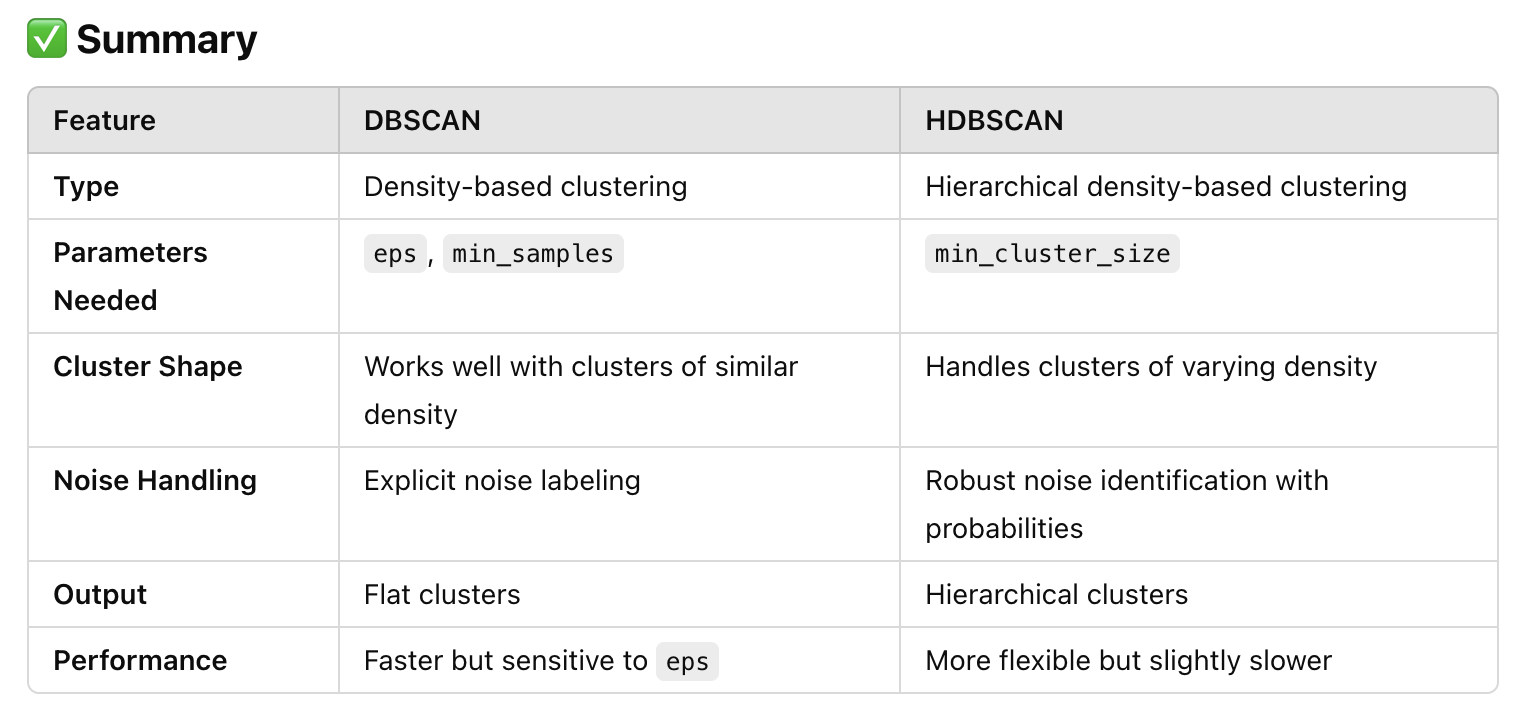

💡 When to Use Each  
Use DBSCAN if you know the expected density and want faster results.  
Use HDBSCAN if you have varying cluster densities or want fewer parameter tuning challenges.  

## 6.1 Run HDBSCAN Clustering
Key Parameters:

- min_cluster_size=20: Minimum number of points in a cluster.  
- min_samples=5: Minimum number of points to define a core point.  
- cluster_selection_epsilon=0.01: Controls cluster compactness (smaller values → tighter clusters).  
- gen_min_span_tree=True: Enables visualization of hierarchical clustering.

Parameter Tuning Tips:  
- Increase min_cluster_size to get larger clusters.
- Lower min_samples to detect more flexible clusters.
- Adjust cluster_selection_epsilon for tighter or looser clusters.

## 6.2 Visualize Clusters

In [ ]:
# Initialize and fit HDBSCAN model
coords = np.array(list(zip(clipped_gdf_projected.geometry.x, clipped_gdf_projected.geometry.y)))
ncs = 25
ms = 6

# Ensure clipped_gdf is a copy to avoid SettingWithCopyWarning
clipped_gdf_projected = clipped_gdf_projected.copy()

# Initialize and fit HDBSCAN model
HDB_clusterer = hdbscan.HDBSCAN(
    min_cluster_size = ncs,
    min_samples = ms,
    # cluster_selection_epsilon=0.003,
    gen_min_span_tree=True 
)

# Assign clusters using .loc
clipped_gdf_projected.loc[:, "HDB_cluster"] = HDB_clusterer.fit_predict(coords)

# View cluster labels (-1 represents noise/outliers)
# print(clipped_gdf["HDB_cluster"].value_counts())
clipped_gdf_projected

In [ ]:
# Count points per cluster (including noise)
cluster_counts = clipped_gdf_projected["HDB_cluster"].value_counts()
# print(cluster_counts)

# Plot histogram (excluding noise if you prefer)
cluster_counts_no_noise = cluster_counts[cluster_counts.index != -1]

plt.figure(figsize=(10, 6))
plt.hist(cluster_counts_no_noise, bins=20, edgecolor='black', color='skyblue')
plt.title("Histogram of HDBSCAN Cluster Sizes (Excluding Noise)")
plt.xlabel("Cluster Size (Number of Points)")
plt.ylabel("Number of Clusters")
plt.axvline(20, color='red', linestyle='--', label='min_cluster_size')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Get persistence per cluster
persistence = HDB_clusterer.cluster_persistence_
print("Cluster persistences:", persistence)

In [ ]:
n_total = len(clipped_gdf_projected)
n_noise = (clipped_gdf_projected['HDB_cluster'] == -1).sum()
print(f"Noise points: {n_noise} / {n_total} ({n_noise/n_total:.2%})")

In [ ]:
# Condensed tree
HDB_clusterer.condensed_tree_.plot(select_clusters=True, selection_palette=sns.color_palette('deep', 8))
plt.show()

This tells you:
- How the hierarchy of clusters was built
- Which clusters are "strong" and at what lambda level they split

In [ ]:
mask = clipped_gdf_projected["HDB_cluster"] != -1
coords_valid = coords[mask]
labels_valid = clipped_gdf_projected.loc[mask, "HDB_cluster"]

if len(set(labels_valid)) > 1:
    score = silhouette_score(coords_valid, labels_valid)
    print(f"Silhouette score (excluding noise): {score:.3f}")
else:
    print("Too few clusters for silhouette score.")

## 6.3 Fine Tuning (Robusntess) 

In [ ]:
# Prepare lists of parameters to try
min_cluster_sizes = [15, 20, 30, 40]
min_samples_list = [4, 6, 8, 10]

results = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)
    for min_cluster_size in min_cluster_sizes:
        for min_samples in min_samples_list:
            clusterer = hdbscan.HDBSCAN(
                min_cluster_size=min_cluster_size,
                min_samples=min_samples,
                gen_min_span_tree=False
            )
            labels = clusterer.fit_predict(coords)
            
            # Calculate noise ratio
            noise_ratio = np.sum(labels == -1) / len(labels)
            
            # Number of clusters (excluding noise)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            
            # Calculate average cluster persistence (if clusters found)
            if n_clusters > 0:
                persistence_avg = np.mean(clusterer.cluster_persistence_)
            else:
                persistence_avg = np.nan
            
            # Silhouette score calculation (exclude noise points)
            if n_clusters > 1:
                mask = labels != -1
                sil_score = silhouette_score(coords[mask], labels[mask])
            else:
                sil_score = np.nan
            
            results.append({
                "min_cluster_size": min_cluster_size,
                "min_samples": min_samples,
                "noise_ratio": noise_ratio,
                "n_clusters": n_clusters,
                "avg_persistence": persistence_avg,
                "silhouette_score": sil_score
            })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Sort results by silhouette score descending (best clustering first)
results_df = results_df.sort_values(by="silhouette_score", ascending=False)

results_df

## 6.4 Optional: Cluster Probability & Stability
HDBSCAN provides additional insights:  
- Probability: Likelihood that each point belongs to its assigned cluster.
- Stability: Stability of each cluster (higher is better).

In [ ]:
# Get the cluster labels for each point
labels = HDB_clusterer.labels_

clipped_gdf_projected["probability"] = HDB_clusterer.probabilities_

# Create a mapping from cluster label to its stability value (skip noise label -1)
# Ensure you only consider non-noise clusters
valid_clusters = [label for label in np.unique(labels) if label != -1]
stability_values = HDB_clusterer.cluster_persistence_

# Create a dictionary: cluster label -> stability
stability_dict = {label: stability for label, stability in zip(valid_clusters, stability_values)}

# Map each point's label to its stability value; assign NaN for noise points (-1)
clipped_gdf_projected['stability'] = clipped_gdf_projected['HDB_cluster'].apply(lambda x: stability_dict.get(x, np.nan))
# clipped_gdf
print(clipped_gdf_projected[["HDB_cluster", "probability", "stability"]].head())

In [ ]:
# High-confidence core points in stable clusters
core_points = clipped_gdf_projected[(clipped_gdf_projected["probability"] > 0.9) & (clipped_gdf_projected["stability"] > 0.1)]

# Low-stability clusters
weak_clusters = clipped_gdf_projected[(clipped_gdf_projected["stability"] < 0.05) & (clipped_gdf_projected["HDB_cluster"] != -1)]

# Visualize or summarize noise
noise_points = clipped_gdf_projected[clipped_gdf_projected["HDB_cluster"] == -1]

In [ ]:
# ----------- Quantify Clusters -----------

# Total number of clusters (excluding noise)
n_clusters = clipped_gdf_projected["HDB_cluster"].nunique() - (1 if -1 in clipped_gdf_projected["HDB_cluster"].unique() else 0)

# Noise percentage
noise_ratio = (clipped_gdf_projected["HDB_cluster"] == -1).sum() / len(clipped_gdf_projected)

print(f"Number of clusters: {n_clusters}")
print(f"Noise percentage: {noise_ratio:.2%}")

In [ ]:
# ----------- Examine Cluster Properties -----------
cluster_summary = (
    clipped_gdf_projected[clipped_gdf_projected["HDB_cluster"] != -1]
    .groupby("HDB_cluster")
    .agg(
        n_points=("HDB_cluster", "count"),
        mean_prob=("probability", "mean"),
        min_prob=("probability", "min"),
        max_prob=("probability", "max"),
        stability=("stability", "first")  # all points in a cluster have same stability
    )
    .sort_values("stability", ascending=False)
)

print(cluster_summary.head())

In [ ]:
# ----------- Filter & Categorize Clusters ----------- 

# Example thresholds (adjust if needed)
stability_threshold = 0.1
prob_threshold = 0.9

clipped_gdf_projected["cluster_quality"] = clipped_gdf_projected.apply(
    lambda row: (
        "Noise" if row["HDB_cluster"] == -1 else
        "Strong" if (row["stability"] > stability_threshold and row["probability"] > prob_threshold)
        else "Weak"
    ),
    axis=1
)

print(clipped_gdf_projected["cluster_quality"].value_counts())

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))
clipped_gdf_projected.plot(column="cluster_quality", ax=ax, legend=True, cmap="Set1", markersize=5, alpha=0.8)
boundary_projected.plot(ax=ax, color='none', edgecolor='black', linewidth=1, label="Boundary")
slums_gdf_projected.plot(ax=ax, color='lightgrey', edgecolor="lightgrey", alpha=0.5, label="Slum Areas")

plt.title("Fly-Tipping Clusters by Quality")

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

# Plot clusters colored by persistence
clipped_gdf_projected.plot(
    ax=ax,
    column='stability',
    cmap='viridis',         # Change color map if preferred
    legend=True,
    markersize=10,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.1
)

boundary_projected.plot(ax=ax, color='none', edgecolor='black', linewidth=1, label="Boundary")
slums_gdf_projected.plot(ax=ax, color='lightgrey', edgecolor="lightgrey", alpha=0.5, label="Slum Areas")

# Title and labels
ax.set_title("HDBSCAN Clustering Colored by Cluster Persistence")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Calculate summary stats
n_clusters = clipped_gdf_projected["HDB_cluster"].nunique() - (1 if -1 in clipped_gdf_projected["HDB_cluster"].unique() else 0)
noise_ratio = (clipped_gdf_projected["HDB_cluster"] == -1).sum() / len(clipped_gdf_projected)

# # Annotation text box
# param_text = (
#     "HDBSCAN Parameters:\n"
#     "min_cluster_size = 30\n"
#     "min_samples = 8\n"
#     f"Detected clusters = {n_clusters}\n"
#     f"Noise ratio ≈ {noise_ratio:.2%}"
# )
# ax.text(
#     0.01, 0.99,
#     param_text,
#     transform=ax.transAxes,
#     fontsize=10,
#     verticalalignment='top',
#     bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray')
# )

plt.tight_layout()
plt.savefig("HDBSCAN_Persistence_Map.png", dpi=300, bbox_inches='tight')
plt.show()

| Column                    | Meaning                                                              |
| ------------------------- | -------------------------------------------------------------------- |
| `cluster` / `HDB_cluster` | The assigned cluster label for each point (`-1` = noise)             |
| `probability`             | HDBSCAN soft clustering confidence (0–1), how likely a point belongs |
| `cluster_quality`         | Often derived from stability, combines size and persistence          |
| `distance_to_slum`        | Your own variable (not part of HDBSCAN)                              |
| `centroid`                | Likely centroid of each cluster                                      |
| `HDB_distance_to_slum`    | Possibly average slum distance per cluster                           |
| `Gi*`, `p_value`          | From hot spot analysis / spatial stats, not from HDBSCAN             |


In [ ]:
cluster_stats = (
    clipped_gdf_projected[clipped_gdf_projected["HDB_cluster"] != -1]
    .groupby("HDB_cluster")["geometry"]
    .apply(lambda x: MultiPoint(list(x)).convex_hull)
    .to_frame(name="geometry")
)

cluster_stats["area_m2"] = cluster_stats.geometry.area
cluster_stats["n_points"] = clipped_gdf_projected.groupby("HDB_cluster").size()
cluster_stats["density_per_km2"] = cluster_stats["n_points"] / (cluster_stats["area_m2"] / 1e6)

print(cluster_stats[["n_points", "area_m2", "density_per_km2"]].sort_values("density_per_km2", ascending=False))

## Save Result 

In [ ]:
# clipped_gdf.to_file("fly_tipping_clusters.geojson", driver="GeoJSON")

## Match with informal settlements

In [ ]:
# # Spatial Join: Points Inside Informal Settlements
# points_in_informal = gpd.sjoin(clipped_gdf_projected, slums_gdf_projected, how='inner', predicate='within')

# # Cluster Counts Within Informal Settlements
# counts_per_cluster = points_in_informal['HDB_cluster'].value_counts()

# # Proportion of Each Cluster Inside Informal Settlements
# all_counts = clipped_gdf_projected['HDB_cluster'].value_counts()
# prop_in_informal = (counts_per_cluster / all_counts).fillna(0)

In [ ]:
# # (Optional) Clusters Near Informal Settlements

# buffered_informal = slums_gdf_projected.buffer(50)  # 50 meters as an example
# buffered_gdf = gpd.GeoDataFrame(geometry=buffered_informal, crs=slums_gdf_projected.crs)
# nearby_points = gpd.sjoin(clipped_gdf_projected, buffered_gdf, how='inner', predicate='intersects')

In [ ]:
# # Calculate distance from each point to informal settlements (slums_gdf)
# clipped_gdf_projected['distance_to_slum'] = clipped_gdf_projected.geometry.apply(lambda point: slums_gdf_projected.distance(point).min())

# # Summary statistics
# print(clipped_gdf_projected['distance_to_slum'].describe())

In [ ]:
# fig, ax = plt.subplots(figsize=(10, 10))
# slums_gdf_projected.plot(ax=ax, facecolor='none', edgecolor='red', label='Informal Areas')
# clipped_gdf_projected.plot(ax=ax, column='HDB_cluster', cmap='tab20', markersize=5, legend=True)

# plt.title("HDBSCAN Clusters vs Informal Settlements")
# # plt.legend()
# plt.tight_layout()
# plt.show()

| Metric               | Description                                                              | Interpretation                                                                                                          |
| -------------------- | ------------------------------------------------------------------------ | ----------------------------------------------------------------------------------------------------------------------- |
| `counts_per_cluster` | Number of points per cluster that fall **within** informal settlements   | Indicates which clusters are **spatially embedded** in informal areas                                                   |
| `prop_in_informal`   | Proportion of each cluster's points that are within informal settlements | Tells you how **informal-focused** a cluster is — values near 1 mean **entirely informal**, near 0 means mostly outside |
| `all_counts`         | Total size of each cluster                                               | Helps you **normalize** comparisons (e.g. to see if large clusters are disproportionately informal)                     |


In [ ]:
# # import matplotlib.pyplot as plt
# %matplotlib inline

# # Sort by proportion
# sorted_prop = prop_in_informal.sort_values(ascending=False)

# plt.figure(figsize=(12, 6))
# sorted_prop.plot(kind='bar', color='tomato')
# plt.title("Proportion of Cluster Points Inside Informal Settlements")
# plt.ylabel("Proportion")
# plt.xlabel("Cluster Label")
# plt.axhline(0.5, color='gray', linestyle='--', label='50% threshold')
# plt.legend()
# plt.tight_layout()
# plt.show()

In [ ]:
# # Make sure prop_in_informal is a Series
# sorted_prop = prop_in_informal.sort_values(ascending=False)

# # Convert to DataFrame for Seaborn
# df = pd.DataFrame({
#     'Cluster': sorted_prop.index.astype(str),
#     'Proportion': sorted_prop.values
# })

# # Plot
# plt.figure(figsize=(14, 6))
# sns.barplot(
#     data=df,
#     x='Cluster',
#     y='Proportion',
#     hue='Cluster',          # assign hue
#     palette='Reds_r',
#     dodge=False,            # keep bars single (no grouping)
#     legend=False            # remove redundant legend
# )

# plt.axhline(0.5, color='gray', linestyle='--', label='50% threshold')

# plt.title("Proportion of Cluster Points Inside Informal Settlements")
# plt.ylabel("Proportion")
# plt.xlabel("Cluster Label")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

In [ ]:
# inside = counts_per_cluster.reindex(all_counts.index).fillna(0)
# outside = all_counts - inside

# df_stack = pd.DataFrame({'Inside': inside, 'Outside': outside})

# df_stack.plot(kind='bar', stacked=True, figsize=(14,6), color=['firebrick', 'lightgray'])
# plt.title("Cluster Composition: Inside vs Outside Informal Settlements")
# plt.ylabel("Number of Points")
# plt.xlabel("Cluster Label")
# plt.legend()
# plt.tight_layout()
# plt.show()

In [ ]:
# # Exclude noise from total cluster counts
# all_counts = clipped_gdf_projected[clipped_gdf_projected['HDB_cluster'] != -1]['HDB_cluster'].value_counts()

# # Count how many cluster points are within informal settlements
# counts_per_cluster = points_in_informal['HDB_cluster'].value_counts()

# # Compute the proportion
# prop_in_informal = (counts_per_cluster / all_counts).fillna(0).sort_index()
# prop_in_informal

##  Distance-Based Metrics

In [ ]:
# # Calculate centroid of each cluster
# clipped_gdf_projected["centroid"] = clipped_gdf_projected.groupby("HDB_cluster")["geometry"].transform(lambda x: MultiPoint(x.tolist()).centroid)

# # Compute minimum distance to slum boundary
# clipped_gdf_projected["HDB_distance_to_slum"] = clipped_gdf_projected["centroid"].apply(lambda x: slums_gdf_projected.distance(x).min())

# # Average distance
# print("Average distance to slum boundary (m):", clipped_gdf_projected["HDB_distance_to_slum"].mean())

# # Proportion within 500m buffer
# within_500m = clipped_gdf_projected[clipped_gdf_projected["HDB_distance_to_slum"] <= 500]
# print("Proportion of clusters within 500m of slums:", len(within_500m) / len(clipped_gdf_projected))

# # Proportion within 2km buffer
# within_2000m = clipped_gdf_projected[clipped_gdf_projected["HDB_distance_to_slum"] <= 2000]
# print("Proportion of clusters within 2km of slums:", len(within_2000m) / len(clipped_gdf_projected))

In [ ]:
# # Simulated data: distance from cluster centroid to slum boundary (in meters)
# np.random.seed(42)

# # Range of buffer distances (100m to 2000m in steps of 100m)
# buffer_distances = np.arange(0, 2100, 10)
# proportions_within_distance = []

# # Calculate proportion within each buffer distance
# for distance in buffer_distances:
#     proportion = (clipped_gdf_projected["HDB_distance_to_slum"] <= distance).mean()
#     proportions_within_distance.append(proportion)

# # Plot results
# plt.figure(figsize=(10, 6))
# plt.plot(buffer_distances, proportions_within_distance, marker='o', linestyle='-', linewidth=2)
# plt.xlabel("Distance to Slum Boundary (m)")
# plt.ylabel("Proportion of Clusters Within Distance")
# plt.title("Proportion of Clusters Within Varying Distances from Slum Boundaries")
# plt.grid(True)
# plt.show()

# Hotspot Analysis (Getis-Ord Gi)* 这个不对-不应该用cluster

In [ ]:
# # Check all column data types
# print(clipped_gdf_projected.dtypes)

# # Check a specific column type
# print(clipped_gdf_projected["HDB_distance_to_slum"].dtype)

In [ ]:
# # Convert cluster column to float
# clipped_gdf_projected["HDB_cluster"] = clipped_gdf_projected["HDB_cluster"].astype(float)

# # Create spatial weight matrix
# w = Queen.from_dataframe(clipped_gdf_projected, use_index=False)
# w.transform = "R"

# # Calculate Gi*
# gi_star = G_Local(clipped_gdf_projected["HDB_cluster"], w)

# # Add to GeoDataFrame
# clipped_gdf_projected["Gi*"] = gi_star.Zs

# clipped_gdf_projected.plot(column="Gi*", cmap="coolwarm", legend=False)
# boundary_projected.plot(ax=ax, color='black', edgecolor='black', linewidth=1, label="Boundary")
# # slums_gdf.plot(ax=ax, color='lightgrey', edgecolor="lightgrey", alpha=0.5, label="Slum Areas")

In [ ]:
# # Display Gi* Z-scores and their significance
# print(clipped_gdf_projected[["Gi*"]].describe())  # Summary stats
# print(clipped_gdf_projected.sort_values("Gi*", ascending=False).head())  # Top hotspots

In [ ]:
# # Get significant hotspots (95% confidence)
# hotspots = clipped_gdf_projected[clipped_gdf_projected["Gi*"] > 1.96]
# coldspots = clipped_gdf_projected[clipped_gdf_projected["Gi*"] < -1.96]

# print(f"Hotspots count: {len(hotspots)}")
# print(f"Coldspots count: {len(coldspots)}")

In [ ]:
# ax = clipped_gdf_projected.plot(column="Gi*", cmap="coolwarm", legend=True, figsize=(12, 8))
# slums_gdf_projected.plot(ax=ax, color="lightgrey", edgecolor="black", alpha=0.5, label="Slums")
# boundary_projected.plot(ax=ax, color='none', edgecolor='black', linewidth=1, label="Boundary")

# plt.title("Waste Pile Hotspots (Gi*) Near Slum Areas")
# plt.legend()
# plt.show()

In [ ]:
# # Spatial join to find hotspots within slums
# hotspots_in_slums = gpd.sjoin(hotspots, slums_gdf, how="inner")
# print(f"Hotspots overlapping slums: {len(hotspots_in_slums)}")

In [ ]:
# # Add p-values to GeoDataFrame (from Gi* object)
# clipped_gdf["p_value"] = gi_star.p_sim  # Assuming gi_star is your G_Local object
# significant = clipped_gdf[clipped_gdf["p_value"] < 0.05]